# Tutorial 1: Acquiring Tidal Data (`module_tidal`)

This tutorial explains how to retrieve tidal data from NOAA APIs using the `process_tidal_data` function. Follow the steps below to process and visualize tidal data.

1. **Import Required Modules**  
Import the `process_tidal_data` function from the `vital.module_tidal` module and `matplotlib.pyplot` for data visualization.

In [1]:
from vital.module_tidal import process_tidal_data
import matplotlib.pyplot as plt

import urllib3

# Suppress InsecureRequestWarning
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

2. **Define Parameters**  
   Set the NOAA station identifier and the start date for tidal data retrieval.

   You can find available NOAA station locations here:  
   [NOAA Currents Station Locations](https://tidesandcurrents.noaa.gov/noaacurrents/index.html)  

   For Alaska-specific data, refer to:  
   [Alaska NOAA Currents Stations](https://tidesandcurrents.noaa.gov/noaacurrents/stations.html?g=693)  

   - Older station IDs starting with `PCT` may cause errors due to limited or outdated data.  
   - Specify the start date for tidal data retrieval in the format `YYYY-MM-DD`.

In [2]:
station = "COI1210"  # NOAA station identifier
startdate = "2020-01-01"  # Start date (format: 'YYYY-MM-DD')

3. **Process Tidal Data**  
   Use the `process_tidal_data` function to retrieve and process tidal data in one step.

In [3]:
results = process_tidal_data(
    station=station,
    startdate=startdate
)

4. **Access Results**  
   Print key attributes of the retrieved tidal data, such as mooring distance, buoy location, station name, nearest city, and cable length.

In [4]:
print(f"Mooring Distance (m): {results.mooring_distance}")
print(f"Buoy Latitude (rad): {results.latitude}")
print(f"Buoy Longitude (rad): {results.longitude}")
print(f"Station Name: {results.station_name}")
print(f"Nearest City: {results.nearest_city}")
print(f"Cable Length (m): {results.cable_length}")

Mooring Distance (m): 43.3
Buoy Latitude (rad): 1.0626780980630117
Buoy Longitude (rad): -2.639508202614978
Station Name: Middle Ground Shoal, E of.
Nearest City: Anchorage
Cable Length (m): 80705.88


5. **Visualize Flow Speeds**  
   Plot the flow speeds over time to analyze tidal conditions.

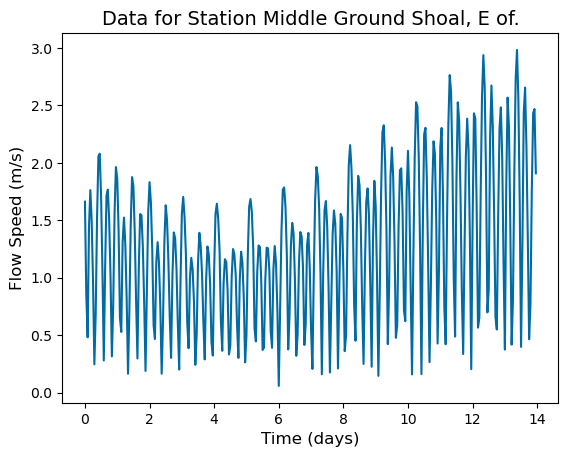

In [5]:
plt.figure()
plt.plot(results.times/(3600*24), results.flow_speeds)
plt.xlabel("Time (days)", fontsize=12)
plt.ylabel("Flow Speed (m/s)", fontsize=12)
plt.title(f"Data for Station {results.station_name}", fontsize=14)
plt.show()